# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [5]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [13]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [4]:

# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [5]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Diagnóstico final:

Dataset users_latam.csv
La columna city presenta un 11.73% de valores faltantes, una proporción moderada que no justifica eliminar registros completos. Dado que la ciudad puede ser útil para futuras segmentaciones geográficas, se investigará para decidir si imputar o dejar como nulos.
La columna churn_date contiene un 88.35% de valores nulos. Aunque el porcentaje es muy elevado, estos nulos parecen indicar clientes que no han cancelado el servicio. Por lo tanto, no se consideran un problema de calidad de datos y no requieren imputación.

Dataset usage.csv
La columna date presenta únicamente un 0.13% de valores faltantes, una proporción muy pequeña que puede resolverse eliminando esos registros o imputándolos mediante una regla de negocio adecuada.
La columna duration contiene un 55.19% de valores nulos. Tras revisar la estructura del dataset, se observó que estos registros corresponden principalmente a actividades de tipo message, donde la duración de llamada no aplica.
La columna length presenta un 44.74% de valores nulos. Estos casos corresponden a actividades de tipo call, donde la longitud del mensaje no aplica.
Los valores nulos de duration y length representan valores no aplicables y no datos faltantes reales. Por esta razón, no se realizarán imputaciones sobre estas variables.
Para evitar interpretaciones incorrectas, el análisis de duration se realizará únicamente sobre registros de llamadas, mientras que el análisis de length se realizará únicamente sobre registros de mensajes.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [6]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna user_id contiene identificadores únicos de los clientes. Su distribución estadística no aporta información de negocio, ya que se trata únicamente de un identificador y no de una variable analítica. No se observan valores faltantes en esta columna. 

- La columna age muestra que la diferencia entre la media (33.74) y la mediana (47) sugiere una fuerte distorsión causada por los valores negativos extremos como -999 (sentinels). Una vez corregidos estos registros, será necesario recalcular las estadísticas descriptivas para obtener una representación más realista de la distribución de edades de los clientes.

In [8]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas id y user_id corresponden a identificadores de registros y usuarios, respectivamente. Aunque se muestran estadísticas descriptivas para estas variables, su información estadística no tiene interpretación de negocio.

- Las columnas duration y length:
Duration registra la duración de las llamadas. Considerando únicamente los registros con información disponible, la duración típica de una llamada es de aproximadamente 3.5 minutos (mediana), mientras que el promedio es de 5.2 minutos. La media superior a la mediana sugiere una distribución sesgada a la derecha, donde la mayoría de las llamadas son relativamente cortas pero existen algunas llamadas considerablemente más largas que elevan el promedio.
La columna length registra la longitud de los mensajes. La longitud típica es de 50 caracteres (mediana), muy cercana al promedio de 52 caracteres, lo que sugiere una distribución más equilibrada que la observada en las llamadas. Sin embargo, el valor máximo de 1490 caracteres es significativamente superior al percentil 75 (64 caracteres), lo que indica la posible presencia de mensajes atípicamente largos que deberán revisarse durante el análisis de outliers.

In [7]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64


- La columna `city` muestra que los clientes se concentran principalmente en Bogotá, CDMX y Medellín, mientras que ciudades como MTY, GDL y Cali presentan una menor cantidad de usuarios registrados. Además, existen 96 registros sin ciudad identificada (65 en plan Básico y 31 en Premium).
  
- La columna `plan` indica que el plan Básico es el más contratado en todas las ciudades analizadas. De los aproximadamente 4,000 usuarios, cerca de 3,000 pertenecen al plan Básico y alrededor de 1,000 al plan Premium


In [15]:

# explorar columna categórica de usage
usage['type'].value_counts()


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` contiene dos categorías de actividad: text y call. Se observa una distribución relativamente equilibrada, aunque los mensajes de texto (22,092 registros) son ligeramente más frecuentes que las llamadas (17,908 registros). Esto indica que los usuarios utilizan ambos servicios de forma importante, con una ligera preferencia por la mensajería. Además, esta distribución explica la presencia de valores nulos en las columnas duration y length, ya que cada tipo de actividad utiliza únicamente una de estas métricas.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  


- ¿En qué columnas encontraste valores inválidos o sentinels?
En la columna age se identificó el valor -999, que es imposible para una edad humana y claramente corresponde a un valor sentinel.
En la columna city se observó la categoría "?", la cual parece representar ciudades no registradas o desconocidas y puede considerarse otro valor sentinel.
No se identificaron valores inválidos evidentes en las demás columnas. Los valores nulos observados en duration y length son consistentes con el tipo de actividad registrada (call o text) y no corresponden a errores de calidad de datos.

  
- ¿Qué acción tomarías?
En age, reemplazaría el valor -999 por NaN para que sea tratado correctamente como dato faltante y no distorsione las estadísticas descriptivas.
En city, reemplazaría el valor "?" por NaN o por una categoría como "Unknown".
Después de reemplazar los sentinels, recalcularía las estadísticas descriptivas para verificar que las medidas de tendencia central y dispersión reflejen adecuadamente la información de los usuarios.

 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [4]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [5]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [6]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se encontraron valores correspondientes al año 2026, el cual no es un año válido respecto a los años de los cuales tenemos los datos, estos 40 registros del 2026 son inconsistentes y probablemente corresponden a errores de captura o digitación.

In [7]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date` del dataset de uso muestra registros exclusivamente del año 2024, por lo que no se detectaron fechas fuera del rango esperado. Esto sugiere una buena consistencia temporal en los datos de actividad de los usuarios.
Basaremos el análisis en estas fechas.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
Se identificaron 40 registros en la columna reg_date con el año 2026, una fecha posterior al rango temporal del proyecto, ya que los datos sólo deberían existir hasta 2024. Estas fechas se consideran inconsistentes y probablemente corresponden a errores de captura o digitación.

- ¿Qué harías con ellas?
Investigar los registros con fecha de 2026 para determinar si existe un patrón de error que permita corregirlos.
Si no es posible identificar la fecha correcta, reemplazar estas fechas por NaT o excluir los registros de análisis que dependan de la fecha de registro.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [8]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()
users['age'].unique()

array([38., 53., 57., 69., 63., 61., 39., 70., 76., 47., 67., 60., 78.,
       77., 25., 51., 74., 64., 26., 68., 37., 42., 36., 22., 28., 32.,
       40., 44., 49., 43., 79., 59., 46., 56., 58., 50., 54., 33., 24.,
       29., 45., 66., 30., 35., 65., 18., 55., 19., 23., 41., 27., 34.,
       72., 75., 31., 71., 52., 20., 73., 21., 62., 48.])

In [9]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)
users["city"] = users["city"].fillna(pd.NA)

# Verificar cambios
users["city"].unique()


array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali'],
      dtype=object)

In [10]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026,'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts() 



2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [11]:
# Verificación MAR en usage (Missing At Random) para duration
usage[usage['type'] == 'call']['duration'].isna().sum()


0

In [12]:
# Verificación MAR en usage (Missing At Random) para length
usage[usage['type'] == 'text']['length'].isna().sum()


0

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los valores nulos de duration dependen completamente de la variable type. Los registros de tipo text no representan llamadas, por lo que la duración no aplica y aparece como valor nulo.
Los valores nulos de length también dependen completamente de type. Los registros de tipo call no representan mensajes de texto, por lo que la longitud del mensaje no aplica y aparece como valor nulo.
Esto se corroboró contando los nulos para "duration" para filas de datos "call", y viceversa calculando los nulos para "length" cuando se es de tipo "text".
Estos nulos no representan errores de captura ni pérdida de información, sino valores no aplicables para determinados tipos de actividad.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [13]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({"is_text": "sum","is_call": "sum","duration": "sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [14]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes","is_call": "cant_llamadas","duration": "cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [15]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg,on="user_id",how="left")

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [16]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [17]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

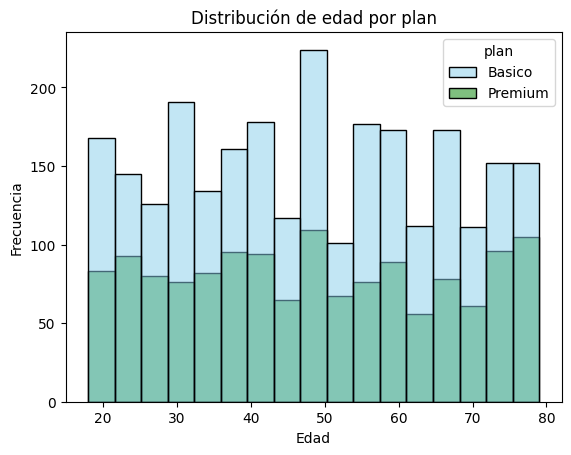

In [22]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución puede considerarse aproximadamente simétrica, sin una cola pronunciada hacia ninguno de los extremos.
- No se observan diferencias importantes entre los usuarios de los planes Básico y Premium, ya que ambos planes están presentes en prácticamente todos los grupos de edad.
- La edad, por sí sola, no parece ser un factor determinante para la elección entre el plan Básico y el Premium.

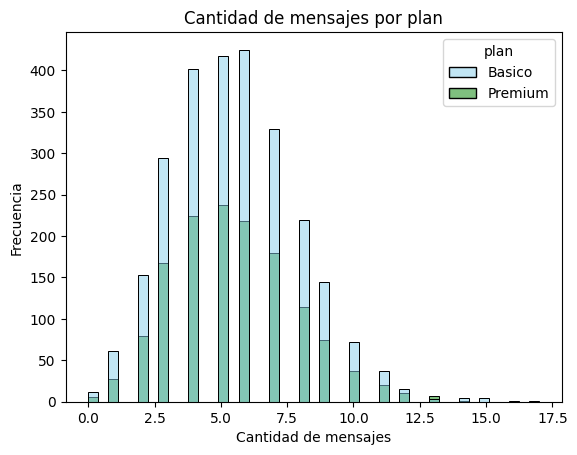

In [23]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Existen pocos usuarios con cantidades muy elevadas de mensajes, por lo que la distribución presenta un ligero sesgo a la derecha.
- La mayoría de los usuarios envía entre 3 y 8 mensajes durante el período analizado.
- Los usuarios de ambos planes muestran patrones de mensajería muy similares.
- El comportamiento de envío de mensajes es bastante similar entre ambos planes, por lo que la mensajería no parece ser un diferenciador importante entre clientes Básico y Premium.

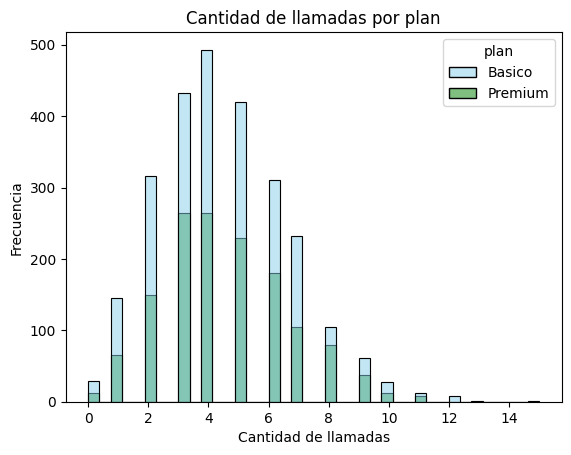

In [24]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución La distribución presenta un sesgo moderado hacia la derecha.
- La mayor parte de los usuarios realiza entre 3 y 6 llamadas.
- Los clientes Premium no muestran un volumen de llamadas significativamente superior al de los clientes Básico, lo que sugiere comportamientos de comunicación similares entre ambos grupos.
- Se observa una disminución gradual de usuarios conforme aumenta el número de llamadas.
- Existen algunos usuarios con más de 10 llamadas, aunque representan una proporción pequeña del total.

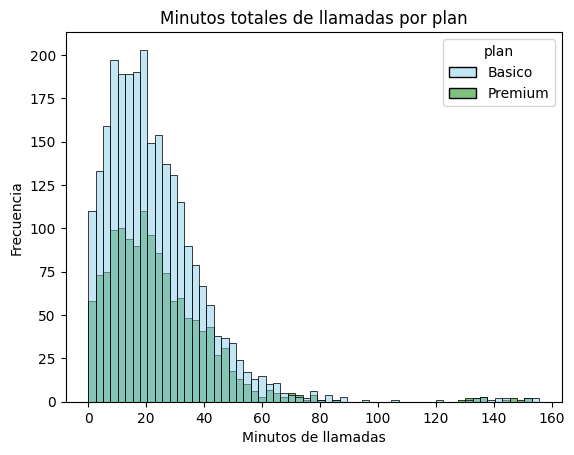

In [25]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Minutos totales de llamadas por plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución muestra un sesgo a la derecha, con una cola larga formada por usuarios de alto consumo.
- La mayoría de los usuarios acumula entre 5 y 35 minutos de llamadas.
- Conforme aumentan los minutos consumidos, la cantidad de usuarios disminuye considerablemente.
- Se observan algunos usuarios con consumos muy elevados (superiores a 100 minutos), los cuales podrían representar valores atípicos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

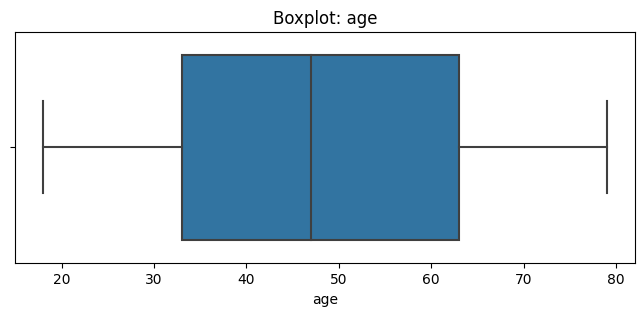

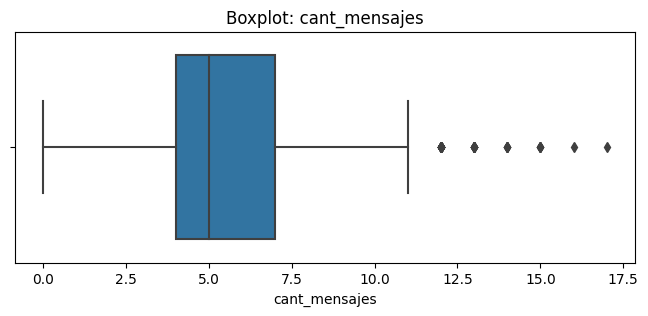

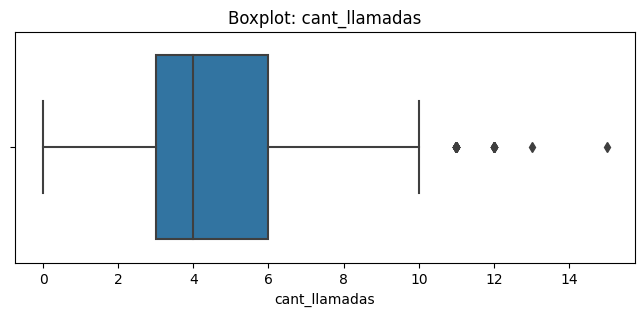

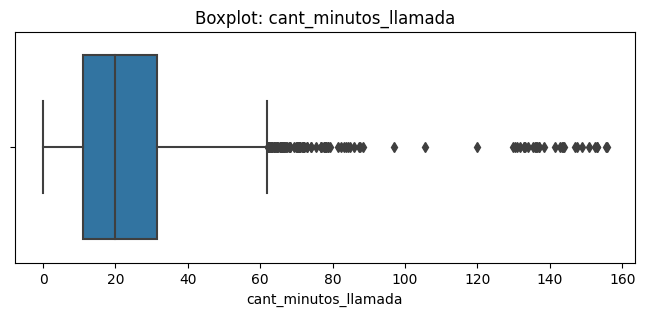

In [18]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for # Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for

💡Insights: 
- Age: No presenta outliers, todos los valores se encuentran dentro de los límites esperados del boxplot.
- cant_mensajes: Sí presenta algunos outliers superiores, cuyos valores aparecen aproximadamente entre 12 y 17 mensajes.
- cant_llamadas: Sí presenta algunos outliers superiores, cuyos valores atípicos se observan aproximadamente entre 11 y 15 llamadas.
- cant_minutos_llamada: Presenta una cantidad importante de outliers superiores. Los valores atípicos parecen representar usuarios de alto consumo.

In [19]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:

    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)

    iqr = q3 - q1

    limite_superior = q3 + 1.5 * iqr

    print(f'\n{col}')
    print(f'Q1: {q1}')
    print(f'Q3: {q3}')
    print(f'IQR: {iqr}')
    print(f'Límite superior: {limite_superior}')
    print(f'Máximo observado: {user_profile[col].max()}')




cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5
Máximo observado: 17.0

cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5
Máximo observado: 15.0

cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575
Máximo observado: 155.69


In [20]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
El método IQR identifica como outliers los usuarios con más de 11.5 mensajes
Se decide mantener los outliers debido a que los valores observados son razonables y probablemente corresponden a usuarios más activos en mensajería, por lo que eliminarlos implicaría perder información relevante sobre segmentos de alto uso.

- cant_llamadas: mantener o no outliers, porqué?
El límite superior calculado es 10.5 llamadas.
Los usuarios identificados como outliers realizan más llamadas que la mayoría, pero siguen encontrándose dentro de un rango realista para un servicio de telecomunicaciones.
Se decide mantener los outliers debido a que no existen indicios de errores de captura ni valores imposibles, estos registros representan clientes con una frecuencia de llamadas superior al promedio.

- cant_minutos_llamada: mantener o no outliers, porqué?
El límite superior calculado mediante IQR es 61.85 minutos.
Esta variable presenta la mayor cantidad de outliers y una marcada asimetría positiva.
Sin embargo, en un negocio de telecomunicaciones es esperable encontrar usuarios con consumos significativamente más altos que el promedio.
Se decide mantener los outliers debido a que los valores elevados parecen reflejar comportamientos reales de usuarios intensivos y constituyen información valiosa para identificar segmentos de alto consumo, diseñar planes diferenciados y detectar oportunidades comerciales.



---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [21]:
# Crear columna grupo_uso

def clasificar_uso(row):

    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'

    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'

    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)


In [22]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [23]:
# Crear columna grupo_edad
def clasificar_edad(row):

    if row['age'] < 30:
        return 'Joven'

    elif row['age'] < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)



In [24]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

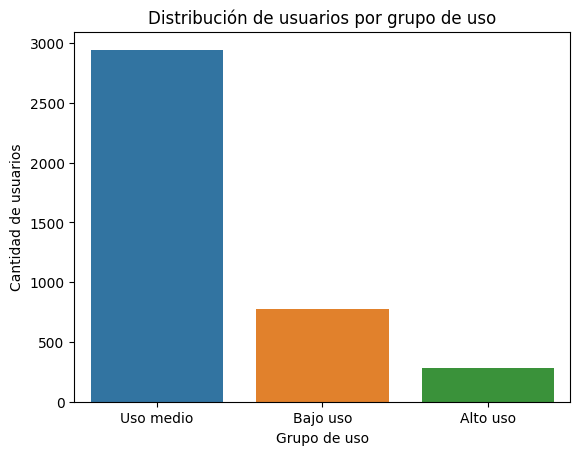

In [25]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=user_profile['grupo_uso'].value_counts().index
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

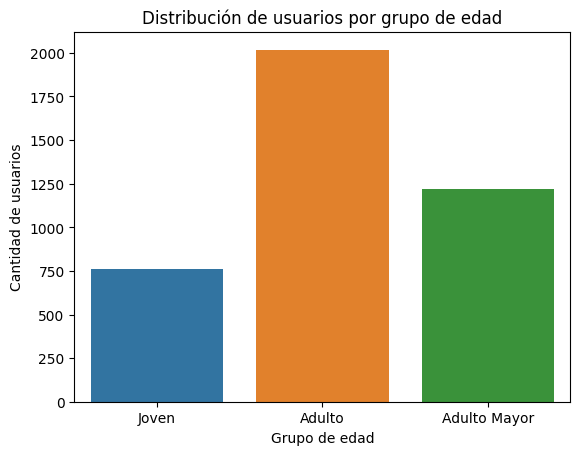

In [27]:
# Visualización de los segmentos por edad

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor']
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron 469 valores nulos en la columna city (11.7%), además de registros con el valor sentinel "?", por lo que se sustituyeron por valores nulos para tratarlos correctamente durante el análisis.
- La columna churn_date presentó 3,534 valores nulos (88.35%). Debido a que una fecha de cancelación sólo existe para usuarios que abandonaron el servicio, estos valores nulos son esperados y no representan un problema de calidad de datos.
- En la columna age se detectó el valor sentinel -999, que generaba una desviación estándar irrealmente alta. Estos registros fueron reemplazados por la mediana de edad (47 años).
- Se identificaron 40 fechas de registro en el año 2026, un año posterior al período analizado (2024), lo que indica errores de captura que fueron marcados como valores faltantes.
- Las columnas duration y length presentaban altos porcentajes de valores nulos (55.2% y 44.7%, respectivamente). Sin embargo, se comprobó que estos nulos dependían completamente del tipo de actividad (call o text), por lo que corresponden a valores no aplicables y no a errores en los datos.


🔍 **Segmentos por Edad**
- Se identificaron tres grupos de edad:
Jóvenes (<30 años). Constituyen el segmento pequeño dentro de la muestra analizada.
Adultos (30 a 59 años). Aproximadamente la mitad de los usuarios de la base.
Adultos mayores (60 años o más). Representan también una proporción importante de la cartera de clientes.

➡️ Esto sugiere que la base de clientes de ConnectaTel está compuesta principalmente por usuarios de mediana edad y adultos mayores, lo que puede influir en las preferencias de uso y en el diseño de futuras ofertas comerciales.


📊 **Segmentos por Nivel de Uso**
- Se identificaron tres segmentos de comportamiento:
Bajo uso: menos de 5 llamadas y menos de 5 mensajes. Es considerablemente bajo el segmento.
Uso medio: menos de 10 llamadas y menos de 10 mensajes. La gran mayoría de los usuarios pertenece a este segmento, representando aproximadamente tres cuartas partes de la cartera.
Alto uso: usuarios que exceden esos límites. Representa la proporción más pequeña de usuarios.

➡️ Esto sugiere que la mayoría de los clientes tiene patrones de consumo moderados y relativamente homogéneos, mientras que sólo una pequeña parte utiliza los servicios de manera intensiva.


💡 **Recomendaciones**
- Diseñar planes especializados para usuarios intensivos
Los usuarios con altos niveles de llamadas y mensajería podrían beneficiarse de planes con mayores beneficios incluidos, reduciendo el riesgo de migración hacia la competencia.
- Desarrollar campañas específicas para adultos y adultos mayores. Estos grupos representan la mayor parte de la cartera y podrían responder positivamente a planes simplificados, beneficios familiares o paquetes orientados a comunicación frecuente.
- Fortalecer los controles de calidad de datos. Implementar validaciones para evitar edades sentinel (-999), ciudades inválidas y fechas futuras permitirá mejorar la confiabilidad de futuros análisis y reportes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`